Hello! Welcome to my notebook. I hope that by reading this you will be able to find helpful information that is useful for the competition.

After researching more, I have decided to use the Random Forest Model, as it seems to yield the lowest RMSE. 

I'll then try various ways to improve on my model, showing the different ways and what works best.

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/house-prices-advanced-regression-techniques/sample_submission.csv
/kaggle/input/house-prices-advanced-regression-techniques/data_description.txt
/kaggle/input/house-prices-advanced-regression-techniques/train.csv
/kaggle/input/house-prices-advanced-regression-techniques/test.csv


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


As always, I'll start with getting a better picture of the dataset:

In [3]:
# reading/assigning the training dataset
df = pd.read_csv('/kaggle/input/house-prices-advanced-regression-techniques/train.csv')

# identifying the contributing factors
df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [4]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

A very mixed combo of objects, ints, and floats

In [6]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


/tmp/ipykernel_19/4041781457.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['SalePrice'], color='g', bins=100, hist_kws={'alpha': 0.4});


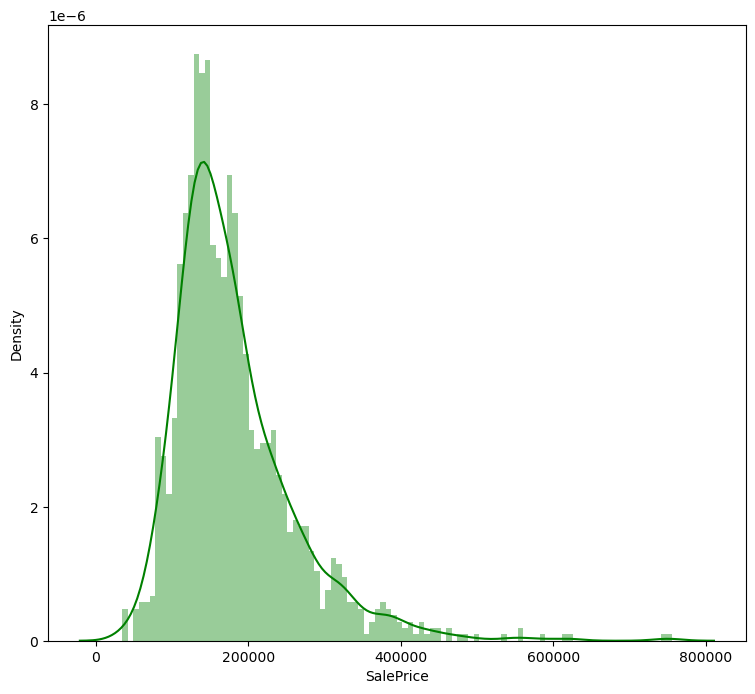

In [7]:
# getting a better picture of the housing price distribution 
# idea adapted from House Prices Prediction using TFDF by Gusthema

print(df['SalePrice'].describe())
plt.figure(figsize=(9, 8))
sns.distplot(df['SalePrice'], color='g', bins=100, hist_kws={'alpha': 0.4});

Time to pre-process the data:

In [8]:
# these are the variables that seem to work best for housing price prediction
X = df[['LotArea', 'YearBuilt','TotalBsmtSF' ,'1stFlrSF', '2ndFlrSF', 'FullBath', 'BedroomAbvGr', 'TotRmsAbvGrd','GarageArea','GrLivArea','MSSubClass','OverallCond']]
X

,LotArea,YearBuilt,TotalBsmtSF,1stFlrSF,2ndFlrSF,FullBath,BedroomAbvGr,TotRmsAbvGrd,GarageArea,GrLivArea,MSSubClass,OverallCond
0,8450,2003,856,856,854,2,3,8,548,1710,60,5
1,9600,1976,1262,1262,0,2,3,6,460,1262,20,8
2,11250,2001,920,920,866,2,3,6,608,1786,60,5
3,9550,1915,756,961,756,1,3,7,642,1717,70,5
4,14260,2000,1145,1145,1053,2,4,9,836,2198,60,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1455,7917,1999,953,953,694,2,3,7,460,1647,60,5
1456,13175,1978,1542,2073,0,2,3,7,500,2073,20,6
1457,9042,1941,1152,1188,1152,2,4,9,252,2340,70,9
1458,9717,1950,1078,1078,0,1,2,5,240,1078,20,6


In [9]:
# this is the target variable, Sale Price
Y = df['SalePrice']
Y

0       208500
1       181500
2       223500
3       140000
4       250000
         ...  
1455    175000
1456    210000
1457    266500
1458    142125
1459    147500
Name: SalePrice, Length: 1460, dtype: int64

In [10]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.20,random_state=42)

In [11]:
from sklearn.metrics import mean_squared_error
import math

In [12]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(random_state = 1)
rf_model.fit(X_train,Y_train)
rf_val_predictions = rf_model.predict(X_test)

pred = rf_model.predict(X_test)

RMSE_1 = math.sqrt(mean_squared_error(pred, Y_test))

print("Random Forest Regressor Model RMSE: ", RMSE_1)

Random Forest Regressor Model RMSE:  30130.879064893277


As you can see, the RMSE for Random Forest is pretty high.

Let's try to lower it.

The following technique was adapted from "House price Prediction", by ANANTHAKRISHNAN K S

In [13]:
# reading the data again, this time I will test it on the test dataset (may prevent overfitting)
train = pd.read_csv("/kaggle/input/house-prices-advanced-regression-techniques/train.csv")
test = pd.read_csv("/kaggle/input/house-prices-advanced-regression-techniques/test.csv")

In [14]:
target = train['SalePrice']
test_ids = test['Id']

train = train.drop(['SalePrice', 'Id'], axis = 1)
test = test.drop(['Id'], axis = 1)

dataset = pd.concat([train, test], axis = 0)
dataset.select_dtypes('object').loc[:, dataset.isna().sum()> 0].columns
categorical_with_none = [
    'Alley',
    'MasVnrType',
    'BsmtQual',
    'BsmtCond',
    'BsmtExposure',
    'BsmtFinType1',
    'BsmtFinType2',
    'FireplaceQu',
    'GarageType',
    'GarageFinish',
    'GarageQual',
    'GarageCond',
    'PoolQC',
    'Fence',
    'MiscFeature',   
]
categorical = dataset.select_dtypes('object').loc[:, dataset.isna().sum() > 0].columns

In [15]:
for col in categorical_with_none:
    dataset[col] = dataset[col].fillna('None')
for col in categorical:
    mod = dataset[col].mode()[0]
    dataset[col] = dataset[col].fillna(mod)

In [16]:
# selecting the columns
dataset.select_dtypes('object').loc[:, dataset.isna().sum()> 0].columns
dataset.select_dtypes(np.number).loc[:, dataset.isna().sum() > 0].columns

Index(['LotFrontage', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF',
       'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath', 'GarageYrBlt',
       'GarageCars', 'GarageArea'],
      dtype='object')

In [17]:
# defining fill with knn method
def FillWithKNN(dataset, ToFill):
    df = dataset.copy()

    numeric_df = df.select_dtypes(np.number)
    non_na_columns = numeric_df.loc[:, numeric_df.isna().sum() == 0].columns
    y_train = numeric_df.loc[numeric_df[ToFill].isna() == False, ToFill]
    X_train = numeric_df.loc[numeric_df[ToFill].isna() == False, non_na_columns]
    X_test = numeric_df.loc[numeric_df[ToFill].isna() == True, non_na_columns]
    
    knn = KNeighborsRegressor(n_neighbors = 10)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)

    df.loc[df[ToFill].isna() == True, ToFill] = y_pred
    return df

In [18]:
# using KNN to fill dataset
from sklearn.neighbors import KNeighborsRegressor
na_columns = dataset.columns[(dataset.isna().sum()) > 0]
for column in na_columns:
    dataset = FillWithKNN(dataset, column)

In [19]:
train = dataset.iloc[:train.shape[0], :].copy()
test = dataset.iloc[train.shape[0]:, :].copy()
full = [train, test]
for ds in full:
    categories = ds.select_dtypes('object').columns
    for column in categories:
        dic = pd.concat([ds[column], target], axis = 1).groupby(column).mean().sort_values(by = 'SalePrice')
        mp = {}
        p = 0
        for it in dic.index:
            mp[it] = p
            p += 1
        ds[column] = ds[column].map(mp)
    categories = ds.select_dtypes('object').columns

In [20]:
# normalization of data
from sklearn.preprocessing import StandardScaler
X = train.copy()
y = target.copy()
X = StandardScaler().fit_transform(X)
test = StandardScaler().fit_transform(test)

In [21]:
# splitting data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.1, random_state = 8, shuffle = True)

# verifying the shape
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((1314, 79), (146, 79), (1314,), (146,))

In [22]:
# training our improved model
DT_reg = RandomForestRegressor(n_estimators = 100)
DT_reg.fit(X_train, y_train)
pred = DT_reg.predict(X_test)
print("New RF RMSE: ", math.sqrt(mean_squared_error(pred, y_test)))

New RF RMSE:  19677.161302785604


Our new model's RMSE is noticeably smaller than the previous one. However, it is still pretty large.

I'll try improving on it even more.

Submission:

In [23]:
y_pred = DT_reg.predict(test)
submission = pd.DataFrame({
        "Id": range(1461, 2920),
        "SalePrice": y_pred
    })

submission.to_csv('/kaggle/working/submission.csv', index = False)

submission


,Id,SalePrice
0,1461,139205.50
1,1462,168760.23
2,1463,188054.35
3,1464,186693.09
4,1465,201417.72
...,...,...
1454,2915,87838.00
1455,2916,87679.11
1456,2917,167076.39
1457,2918,126870.00


I will continue working on this tomorrow.

Please give me some advice. What should I try, in my effort to improve my models?

Thank you for reading, I hope this was helpful!